# Optimization for Machine Learning: Computer Lab 1

## 2. Preprocessing the data

Here, we load the data, standardize it, and set it in the appropriate shape for performing linear regression. You do not need to complete anything in this section; however it is important that you understand what the code is doing. See the pdf instructions for more details.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Loading data
data_matrix_train, COP_train, data_matrix_test, COP_test, names = np.load('data_center_data_matrix.npy', allow_pickle=True)

In [8]:
# centering and normalizing the matrix
matrix_mean = np.mean(data_matrix_train, axis=0)
M = data_matrix_train - matrix_mean

matrix_std = np.std(M, axis=0)
M = M / matrix_std

In [9]:
M.shape

(722, 892)

In [10]:
# Building the corresponding matrices A,b for linear regression
A = np.hstack([M, np.ones((M.shape[0],1)), -(M.T * COP_train[:,3]).T])
b = COP_train[:,3]

# Building the same matrices for the test set
M_test = (data_matrix_test - matrix_mean) / matrix_std
A_test = np.hstack([M_test, np.ones((M_test.shape[0],1)), -(M_test.T * COP_test[:,3]).T])
b_test = COP_test[:,3]

d = A.shape[1]

## 3. Ordinary least squares

We now wish to solve the problem
$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2
$$

In [11]:
## Question 3.2: solve with the numpy least squares solver

# COMPLETE HERE
w_least_squares =np.linalg.lstsq(A, b, rcond=None)[0]

In [ ]:
## Question 3.3

# COMPLETE HERE
b_test_pred = A_test @ w_least_squares

# Test error (mean squared error)
test_error = np.linalg.norm(b_test_pred - b_test) ** 2

print("Test error for least squares solution : ", test_error)
# print("Test error for least squares solution : ", test_error)

Test error for least squares solution :  780.8984793523891


### Adding $\ell_2$ regularization

In order to improve the performance on the test set, we add $\ell_2$ regularization:

$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2 + \frac \lambda 2 \|w\|_2^2
$$

In [ ]:
lambda_l2 = 1e4

In [ ]:
# Question 3.5
lambda_12=1e4

def f(w):
     return 0.5 * np.linalg.norm(A @ w - b)**2 + 0.5 * lambda_12 * np.linalg.norm(w)**2
    # COMPLETE HERE

def grad_f(w): 
    return (A.T @ (A @ w - b) + lambda_12 * w)
    # COMPLETE HERE

def gradient_descent(f, grad_f, w0, gamma, max_iter):
    w = w0.copy()
    
    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        # COMPLETE HERE 
        w=w - gamma * grad_f(w)
        
        f_values.append(f(w))
        gradient_norms.append(np.linalg.norm(grad_f(w)))
        
    return w, f_values, gradient_norms

For finding the appropriate step size range, we need to estimate the Lipschitz constant of the gradient.

In [ ]:
# COMPLETE HERE
Mat=A.T@A +lambda_12*np.eye(A.shape[1])
L = np.linalg.norm(Mat, ord=np.inf)

In [ ]:
# COMPLETE HERE
w0 = np.zeros(d)
step_size = 1/L 
max_iter = 1000

w_GD, f_values_GD, gradient_norms_GD = gradient_descent(f, grad_f, w0, step_size, max_iter)

We now compute the evolution of function values and gradient norm. 

Text(0, 0.5, 'Function values')

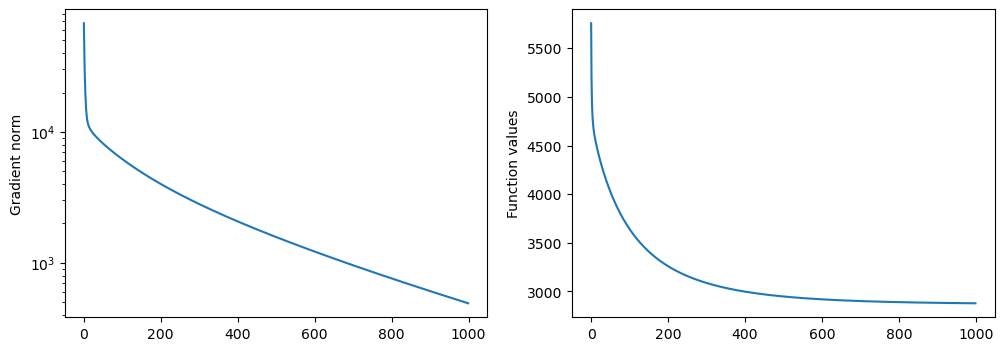

In [ ]:
# let us plot the result 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD)
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm")

axes[1].plot(f_values_GD)
axes[1].set_ylabel("Function values")

In [ ]:
# Question 3.6 
N=len(A_test)
b_test_pred_l2 = A_test @ w_GD 
test_error_l2 = np.linalg.norm(b_test_pred_l2 - b_test) ** 2 # COMPLETE HERE
print("Test error for l2 penalized solution : ", test_error_l2)

Test error for l2 penalized solution :  18368.685877365657


What do you observe ?
We notice that the function value decreases very quickly in the begining before reaching a threshold. 
The gradient norm decreases extremely quickly between 0 and 20. It drecreases exponentialy after 20. 

### Line search

The step size given by theory is can be too conservative in practice. We propose to implement a backtracking line search procedure to find a better one automatically.


In [ ]:
# Question 3.7

def gradient_descent_line_search(f, grad_f, w0, gamma_0, max_iter):
    w = w0.copy()

    # initial step size
    gamma = gamma_0.copy() 
    beta=2
    
    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        # COMPLETE HERE
        while True: 
            w_next= w - gamma*grad_f(w)
            rhs = f(w) + np.dot(grad_f(w), w_next - w) + (1/(2*gamma)) * np.linalg.norm(w_next - w)**2
            if f(w_next) < rhs :
                w=w_next
                gamma=gamma*beta
                break; 
            else: 
                gamma=gamma/beta
                
        f_values.append(f(w))
        gradient_norms.append(np.linalg.norm(grad_f(w)))
        
    return w, f_values, gradient_norms

In [ ]:
# COMPLETE HERE
w0 = np.zeros(d)
step_size = 1 / L
max_iter = 1000


w_GD_LS, f_values_GD_LS, gradient_norms_GD_LS = gradient_descent_line_search(f, grad_f, w0, step_size, max_iter)

C:\Users\MESSOUAK\AppData\Local\Temp\ipykernel_186228\2029526153.py:17: RuntimeWarning: overflow encountered in scalar divide
  rhs = f(w) + np.dot(grad_f(w), w_next - w) + (1/(2*gamma)) * np.linalg.norm(w_next - w)**2
C:\Users\MESSOUAK\AppData\Local\Temp\ipykernel_186228\2029526153.py:17: RuntimeWarning: invalid value encountered in scalar multiply
  rhs = f(w) + np.dot(grad_f(w), w_next - w) + (1/(2*gamma)) * np.linalg.norm(w_next - w)**2
C:\Users\MESSOUAK\AppData\Local\Temp\ipykernel_186228\2029526153.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  rhs = f(w) + np.dot(grad_f(w), w_next - w) + (1/(2*gamma)) * np.linalg.norm(w_next - w)**2


KeyboardInterrupt: 

Text(0, 0.5, 'Function values with line search')

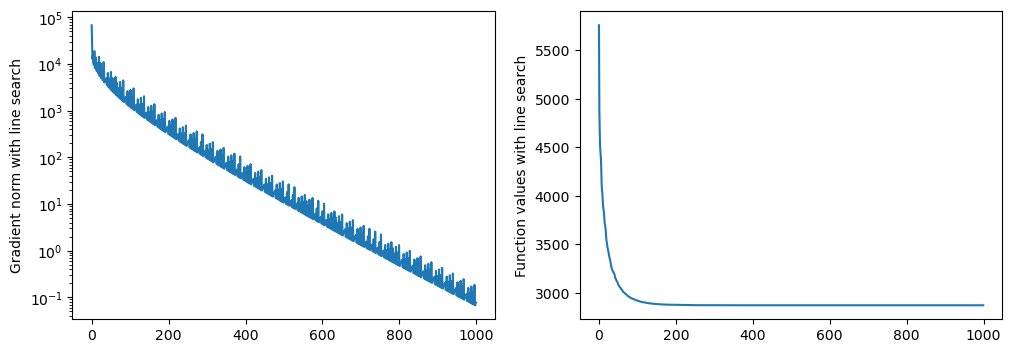

In [ ]:
# let us plot the result 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD_LS)
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm with line search")

axes[1].plot(f_values_GD_LS)
axes[1].set_ylabel("Function values with line search")

### Accelerated gradient method
For a faster algorithm, we could implement accelerated gradient descent.

In [ ]:
# Question 3.8 (optional) 

def accelerated_gradient_descent(f, grad_f, w0, gamma, max_iter):
    # COMPLETE HERE
    w = w0.copy()
    beta=2

    # initial step size
    h=[np.zeros(d),np.zeros(d)]
    
    f_values = []
    gradient_norms = []
    a=0

    for t in range(max_iter):
        # COMPLETE HERE
        a=(t+1)/(t+3)
        while True: 
            
            w_next= w - gamma*grad_f(w)
            rhs = f(w) + np.dot(grad_f(w), w_next - w) + (1/(2*gamma)) * np.linalg.norm(w_next - w)**2
            if f(w_next) < rhs :
                gamma=gamma*beta
                h[0]=h[1]
                h[1]=w_next
                w=h[1]+a*(h[1]-h[0])
                break; 
            else: 
                gamma=gamma/beta
    
        f_values.append(f(w))
        gradient_norms.append(np.linalg.norm(grad_f(w)))
        
    return w, f_values, gradient_norms

In [ ]:
# COMPLETE HERE
w0 = np.zeros(d)
step_size = 1 / L
max_iter = 1000

w_AGD, f_values_AGD, gradient_norms_AGD = accelerated_gradient_descent(f, grad_f, w0, step_size, max_iter)

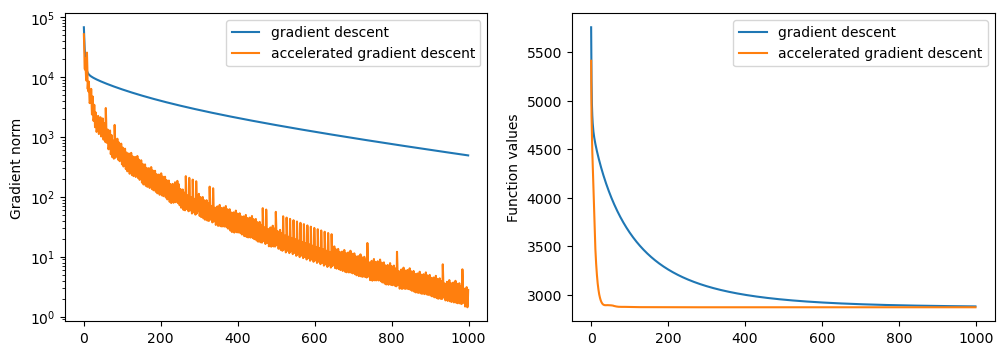

In [ ]:
# let us plot the result 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

axes[0].plot(gradient_norms_GD, label = "gradient descent")
axes[0].plot(gradient_norms_AGD, label = "accelerated gradient descent")
axes[0].semilogy()
axes[0].set_ylabel("Gradient norm")
axes[0].legend()

axes[1].plot(f_values_GD, label = "gradient descent")
axes[1].plot(f_values_AGD, label = "accelerated gradient descent")
axes[1].set_ylabel("Function values")
axes[1].legend()

What do you observe regarding the convergence speed ?
the convergence speed is much more important in the case of a accelerated gradient descent. Indeed the treshold is reached around k=20 for the AGD and around k=1000 for GD. Wich shows how powerfull AGD is. However the graph of the gradient norms shows that the method of AGD becomes less efficient for high values of k since the value of xk doesn't change by much. 

## 4. Adding $\ell_1$ regularization (Lasso)

We now solve 

$$
\min_{w \in \mathbb{R}^d} \frac 12 \|Aw-b\|_2^2 + \lambda \|w\|_1
$$

In [ ]:
lambda_l1=1e3
def f(w):
    return 0.5 * np.linalg.norm(A @ w - b)**2 + lambda_l1 * np.linalg.norm(w, 1)

def grad_f(w):
    return A.T @ (A @ w - b)

def prox_l1(x, mu):
    return np.sign(x) * np.maximum(np.abs(x) - mu, 0)

def proximal_gradient_descent(f, grad_f, w0, gamma, max_iter):
    w = w0.copy()
    f_values = []
    gradient_norms = []

    for t in range(max_iter):
        w = prox_l1(w - gamma * grad_f(w), gamma * lambda_l1)
        f_values.append(f(w))
        gradient_norms.append(np.linalg.norm(grad_f(w)))

    return w, f_values, gradient_norms


In [ ]:
# COMPLETE HERE
w0 = np.zeros (d)
step_size = 1/L
max_iter = 1000


w_PGD, f_values_PGD, gradient_norms_PGD = proximal_gradient_descent(f, grad_f, w0, step_size, max_iter)

In [ ]:
# Question 4.3

test_error_l1 = np.linalg.norm( A_test @ w_PGD- b_test) ** 2

# COMPLETE HERE
print("Test error for l1 penalized solution : ", test_error_l1)

Test error for l1 penalized solution :  3735.2913486168736


Compare with the previous test errors. What do you observe?
We observe that this one is higher than the first one (for norm (aw-b)^2) this is logic since we added a constraint. However it remains very smaller than the middle one (norm((aw-b)^2)+lambda/2* norm w^2) wich shows that using l1 norm can be a good compromise. 

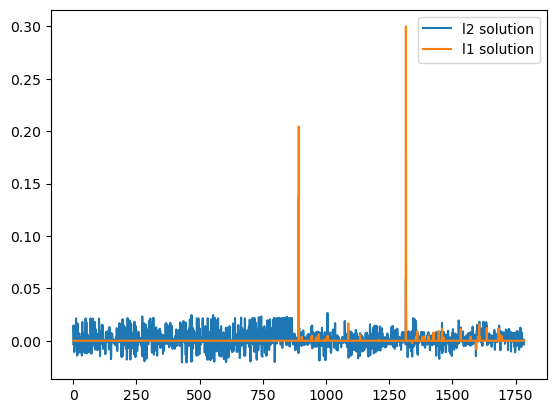

In [ ]:
# Let us examine the solution
plt.plot(w_GD, label = "l2 solution")
plt.plot(w_PGD, label = "l1 solution")
plt.legend()

What do you observe regarding the difference in **structure** of the two solutions? *
We observe that for the L1 case, xk is very close to zero at some k and it also variate more in some places (between 750 and 1000 for instance). While in the L2 case it doesn't variate mush (it remains between -0.03 and 0.03)

## [BONUS] Tuning the penalization parameter

How to find the best solution among all those that were comptued? How to choose the penalization parameter $\lambda$?

In [ ]:
# Your method here...